### Import data analysis libraries

In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lasio as ls
import plotly.express as px # type: ignore

### Import Supervised Machine Learning libraries

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
from xgboost import XGBRegressor

### Import Unsupervised Machine Learning libraries

In [89]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Data Preparation

In [90]:
las_1 = ls.read("Data/5002320003.las")
las_2 = ls.read("Data/5002320005.las")
las_3 = ls.read("Data/5002320007.las")
las_4 = ls.read("Data/5002320008.las")
las_5 = ls.read("Data/5002320009.las")
las_6 = ls.read("Data/5002320011.las")
las_7 = ls.read("Data/5002320012.las")
las_8 = ls.read("Data/5002320014.las")
las_9 = ls.read("Data/5002320016.las")
las_10 = ls.read("Data/5002320018.las")
las_11 = ls.read("Data/5002320019.las")

In [91]:
# Print the curves for each las file
print(las_1.curves)
print(las_2.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
SP        MV           2            
ASN       OHMM         3            
ILD       OHMM         4            
CILD      MMHO         5            
CALI      IN           6            
GR        GAPI         7            
DRHO      G/C3         8            
RHOB      G/C3         9            
DT        US/F         10           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
CALI      IN           2            
GR        GAPI         3            
RHOB      G/C3         4            
NPHI      %            5            
DPHI      %            6            
SP        MV           7            
LL8       OHMM         8            
ILD       OHMM         9            
CILD      MMHO         10           
DT        US/F         11           


In [92]:
print(las_3.curves)
print(las_4.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
SP        MV           2            
ILD       OHMM         3            
LL8       OHMM         4            
ILM       OHMM         5            
RHOB      G/C3         6            
DRHO      G/C3         7            
CALI      IN           8            
GR        GAPI         9            
NPHI      %            10           
DT        US/F         11           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
SP        MV           2            
ILD       OHMM         3            
LL8       OHMM         4            
CILD      MMHO         5            
ILM       OHMM         6            
GR        GAPI         7            
CALI      IN           8            
DRHO      G/C3         9            
RHOB      G/C3         10           
NPHI      %            11           
DPHI      %            12           
D

In [93]:
print(las_5.curves)
print(las_6.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
LLS       OHMM         2            
LLD       OHMM         3            
SP        MV           4            
ILD       OHMM         5            
ILM       OHMM         6            
LL8       OHMM         7            
CALI      IN           8            
GR        GAPI         9            
NPHI      %            10           
DPHI      %            11           
RHOB      G/C3         12           
DRHO      G/C3         13           
DT        US/F         14           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
CALI      IN           2            
GR        GAPI         3            
NPHI      %            4            
RHOB      G/C3         5            
DRHO      G/C3         6            
DT        US/F         7            
SP        MV           8            
ILD       OHMM         9            
I

In [94]:
print(las_7.curves)
print(las_8.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
GR        GAPI         2            
CALI      IN           3            
RHOB      G/C3         4            
DRHO      G/C3         5            
NPHI      %            6            
DT        US/F         7            
SP        MV           8            
ILD       OHMM         9            
ILM       OHMM         10           
LL8       OHMM         11           
LLD       OHMM         12           
LLS       OHMM         13           
MSFL      OHMM         14           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
SP        MV           2            
LLD       OHMM         3            
LLS       OHMM         4            
MSFL      OHMM         5            
CALI      IN           6            
RHOB      G/C3         7            
DRHO      G/C3         8            
NPHI      %            9            
G

In [95]:
print(las_9.curves)
print(las_10.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
CALI      IN           2            
GR        GAPI         3            
RHOB      G/C3         4            
DRHO      G/C3         5            
NPHI      %            6            
DT        US/F         7            
SP        MV           8            
ILD       OHMM         9            
ILM       OHMM         10           
SFL       OHMM         11           
LLD       OHMM         12           
LLS       OHMM         13           
MSFL      OHMM         14           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
GR        GAPI         2            
CALI      IN           3            
RHOB      G/C3         4            
DRHO      G/C3         5            
NPHI      %            6            
DT        US/F         7            
SP        MV           8            
LLS       OHMM         9            
L

In [96]:
print(las_11.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
CALI      IN           2            
DRHO      G/C3         3            
RHOB      G/C3         4            
NPHI      %            5            
DT        US/F         6            
GR        GAPI         7            
SP        MV           8            
MSFL      OHMM         9            
LLS       OHMM         10           
LLD       OHMM         11           


In [97]:
# Convert each las file to a DataFrame
las_1_df = las_1.df()
las_2_df = las_2.df()
las_3_df = las_3.df()
las_4_df = las_4.df()
las_5_df = las_5.df()
las_6_df = las_6.df()
las_7_df = las_7.df()
las_8_df = las_8.df()
las_9_df = las_9.df()
las_10_df = las_10.df()
las_11_df = las_11.df()

In [98]:
las_1_df.head()

,SP,ASN,ILD,CILD,CALI,GR,DRHO,RHOB,DT
DEPT,,,,,,,,,
1088.0,NaN,NaN,NaN,NaN,NaN,49.9702,NaN,NaN,NaN
1088.5,NaN,NaN,NaN,NaN,NaN,50.7592,NaN,NaN,NaN
1089.0,NaN,NaN,NaN,NaN,NaN,52.0155,NaN,NaN,NaN
1089.5,NaN,NaN,NaN,NaN,NaN,52.2536,NaN,NaN,NaN
1090.0,NaN,NaN,NaN,NaN,NaN,52.2993,NaN,NaN,NaN


In [99]:
# Reset the index for each DataFrame
las_1_df = las_1_df.reset_index()
las_2_df = las_2_df.reset_index()
las_3_df = las_3_df.reset_index()
las_4_df = las_4_df.reset_index()
las_5_df = las_5_df.reset_index()
las_6_df = las_6_df.reset_index()
las_7_df = las_7_df.reset_index()
las_8_df = las_8_df.reset_index()
las_9_df = las_9_df.reset_index()
las_10_df = las_10_df.reset_index()
las_11_df = las_11_df.reset_index()

In [100]:
las_1_df.head()

,DEPT,SP,ASN,ILD,CILD,CALI,GR,DRHO,RHOB,DT
0,1088.0,NaN,NaN,NaN,NaN,NaN,49.9702,NaN,NaN,NaN
1,1088.5,NaN,NaN,NaN,NaN,NaN,50.7592,NaN,NaN,NaN
2,1089.0,NaN,NaN,NaN,NaN,NaN,52.0155,NaN,NaN,NaN
3,1089.5,NaN,NaN,NaN,NaN,NaN,52.2536,NaN,NaN,NaN
4,1090.0,NaN,NaN,NaN,NaN,NaN,52.2993,NaN,NaN,NaN


**Standardize Column Names**: Rename shallow resistivity columns (LL8, LLS, etc.) to "RS" and deep resistivity columns (ILD, LLD, etc.) to "Deep_RS".

**Select Common Columns**: Ensure each DataFrame has the required columns (DEPT, NPHI, SP, DT, GR, CALI, RHOB, Deep_RS, and RS). If a DataFrame lacks any of these columns, we’ll remove it from the collection.

We only want to keep the columns/logs that are common among the dataframes.

In [101]:
# List of dataframes to process
dfs = [las_1_df, las_2_df, las_3_df, las_4_df, las_5_df, las_6_df, las_7_df, las_8_df, las_9_df, las_10_df, las_11_df]

# Standardized column names
required_columns = ["DEPT", "NPHI", "SP", "DT", "GR", "CALI", "RHOB", "Deep_RS", "RS"]

# Lists to track processed and removed DataFrames
processed_dfs = []
removed_dfs = []

for i, df in enumerate(dfs):
    # Standardize column names for shallow and deep resistivity
    df = df.rename(columns={
        "LL8": "RS", "LLS": "RS", "MSFL": "RS",
        "ILD": "Deep_RS", "LLD": "Deep_RS", "ILM": "Deep_RS"
    })

    # Check if all required columns are present
    if all(col in df.columns for col in required_columns):
        # Keep only the required columns
        df = df[required_columns]
        processed_dfs.append(df)
    else:
        # Track index of removed DataFrame
        removed_dfs.append(f"las_{i+1}_df")

# Display results
print("DataFrames retained:", [f"las_{i+1}_df" for i in range(len(processed_dfs))])
print("DataFrames removed:", removed_dfs)

DataFrames retained: ['las_1_df', 'las_2_df', 'las_3_df', 'las_4_df', 'las_5_df', 'las_6_df', 'las_7_df', 'las_8_df', 'las_9_df', 'las_10_df']
DataFrames removed: ['las_1_df']


Only **las_1_df** was removed so we'll have a list (processed_dfs) with 10 dataframes, being **processed_df[0] = las_2_df** (filtered) and so on.

In [102]:
processed_dfs[1].head()

,DEPT,NPHI,SP,DT,GR,CALI,RHOB,Deep_RS,Deep_RS,RS
0,151.0,NaN,NaN,149.9976,NaN,13.7672,NaN,NaN,NaN,NaN
1,151.5,NaN,NaN,149.9864,NaN,14.1439,NaN,NaN,NaN,NaN
2,152.0,NaN,-35.9583,149.9753,NaN,14.1713,NaN,3.9695,NaN,7.4901
3,152.5,NaN,-36.5363,149.9641,NaN,14.1778,NaN,2.8051,NaN,7.3950
4,153.0,NaN,-37.0716,149.9529,NaN,14.1762,NaN,2.1887,NaN,7.2999


In [107]:
# Initialize an empty list to store each DataFrame with its source column added
df_list = []

for i, df in enumerate(processed_dfs, start=2):
    # Check for and remove duplicate columns, if any
    df = df.loc[:, ~df.columns.duplicated()].copy()
    
    # Add the source column to identify the origin DataFrame
    df['source'] = f"las_{i}_df"
    df_list.append(df)

# Concatenate all DataFrames in df_list into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)


In [110]:
combined_df

,DEPT,NPHI,SP,DT,GR,CALI,RHOB,Deep_RS,RS,source
0,1260.0,NaN,NaN,NaN,47.5286,NaN,NaN,NaN,NaN,las_2_df
1,1260.5,NaN,NaN,NaN,47.7171,NaN,NaN,NaN,NaN,las_2_df
2,1261.0,NaN,NaN,NaN,47.8198,NaN,NaN,NaN,NaN,las_2_df
3,1261.5,NaN,NaN,NaN,47.6691,NaN,NaN,NaN,NaN,las_2_df
4,1262.0,NaN,NaN,NaN,47.9667,NaN,NaN,NaN,NaN,las_2_df
...,...,...,...,...,...,...,...,...,...,...
54631,4350.0,NaN,-21.2292,NaN,NaN,8.1459,2.4535,14.1724,11.3857,las_11_df
54632,4350.5,NaN,-20.0351,NaN,NaN,NaN,2.4231,14.1607,NaN,las_11_df
54633,4351.0,NaN,-18.6172,NaN,NaN,NaN,2.4156,14.1491,NaN,las_11_df
54634,4351.5,NaN,-19.6531,NaN,NaN,NaN,2.3989,14.1374,NaN,las_11_df


<Axes: >

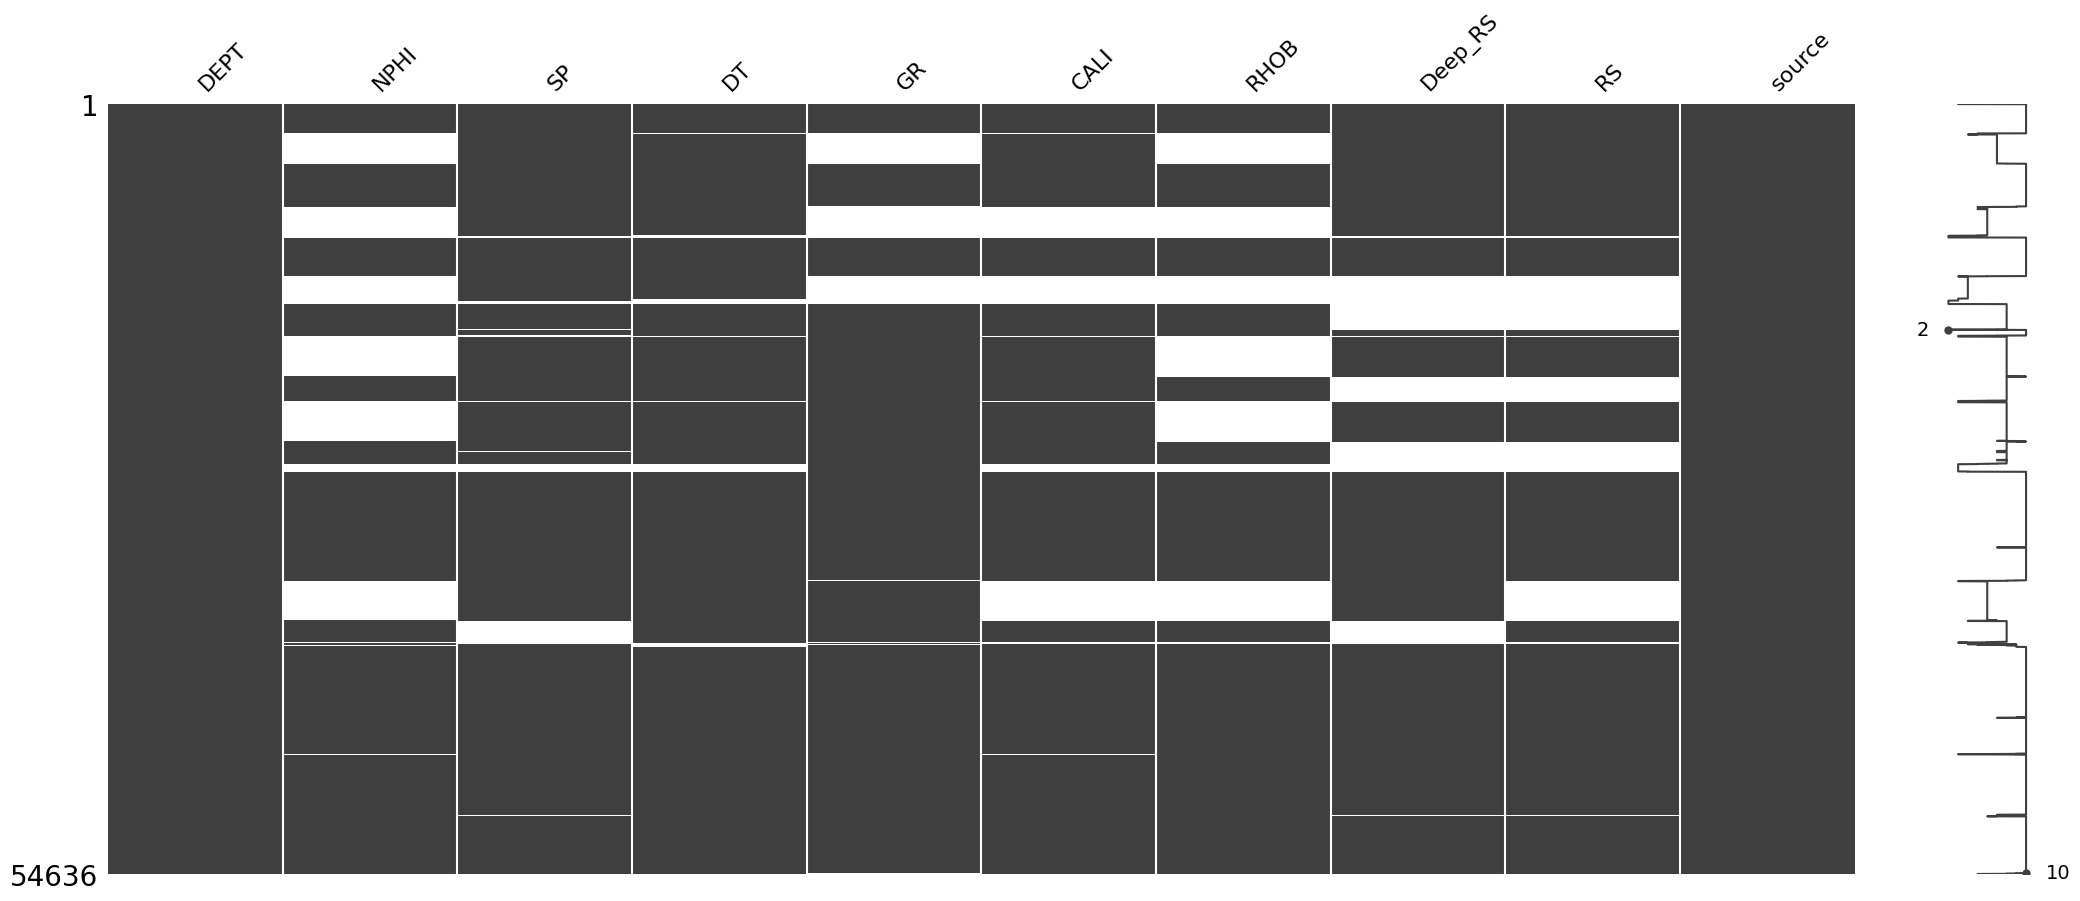

In [111]:
import missingno as msno

msno.matrix(combined_df)

We must have well logs data for every row, so NaN values must be filled or removed. Since there are over 50000 rows, we can just use **dropna**

In [112]:
combined_df.dropna(inplace=True)

<Axes: >

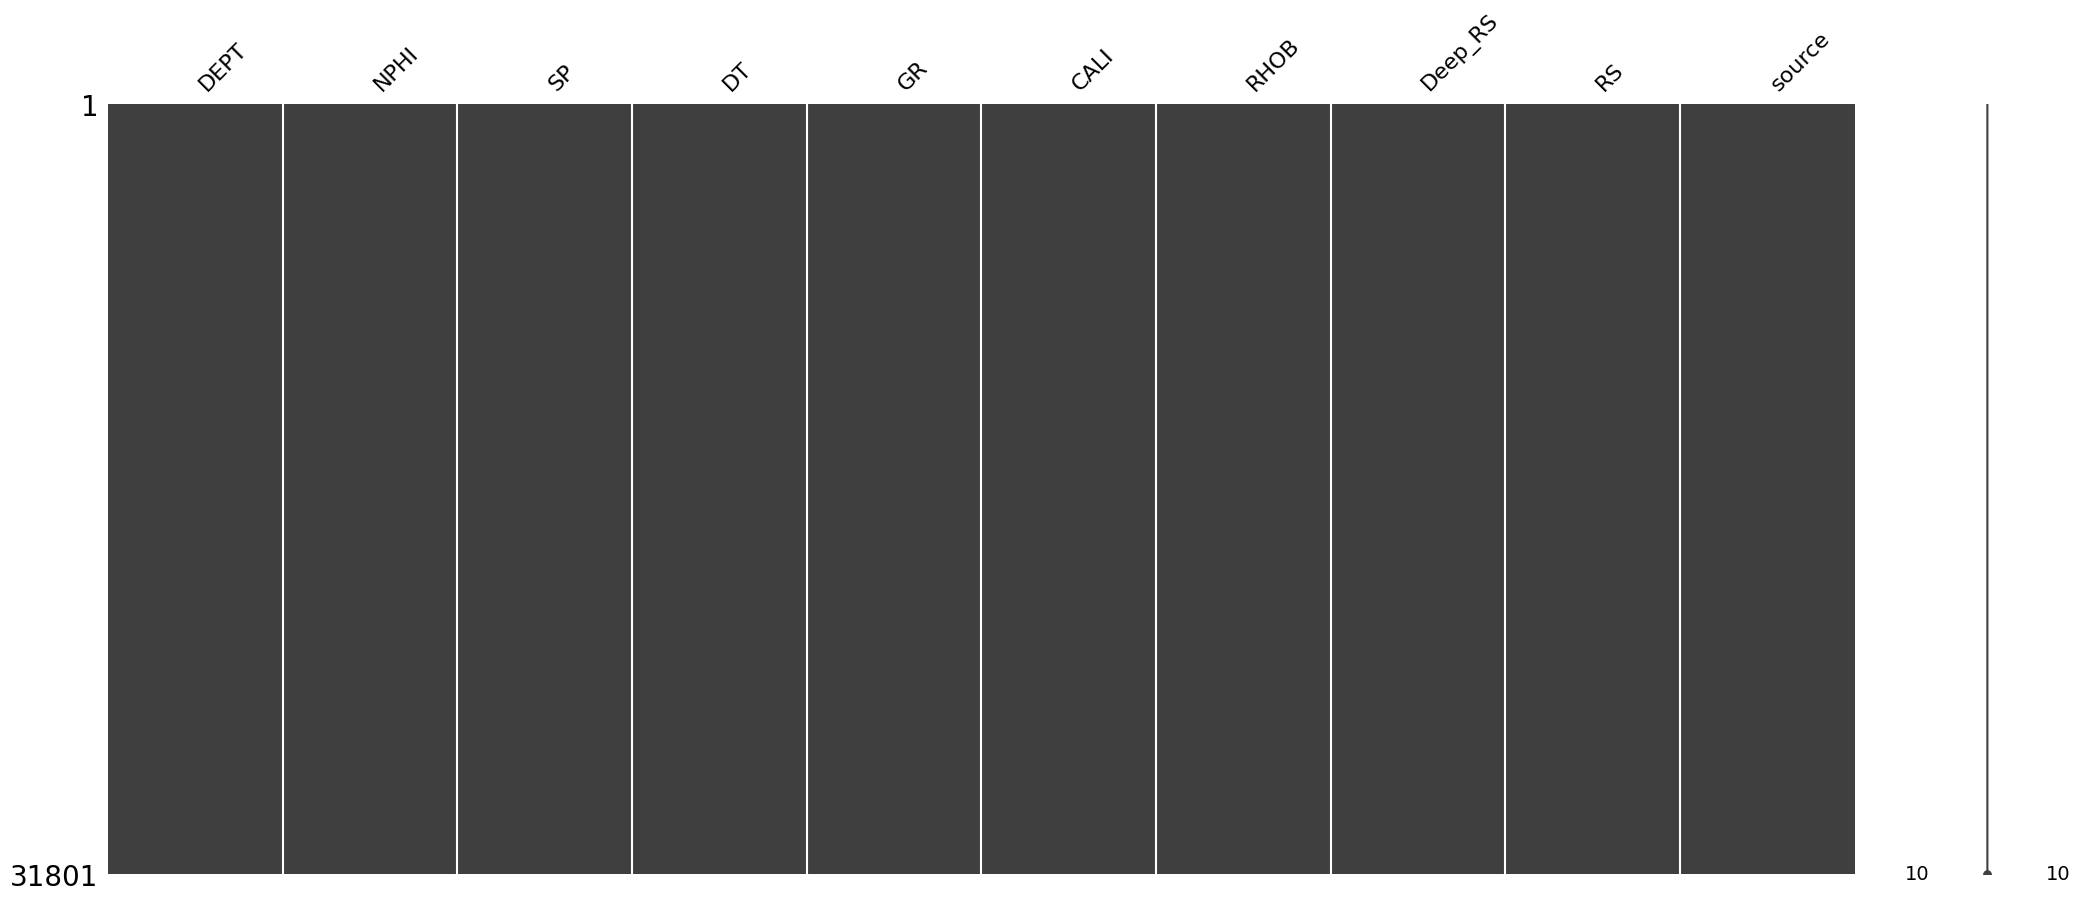

In [113]:
msno.matrix(combined_df)

**Note**: it's important to see which depth ranges don't have data now (differences over 1ft)

In [119]:
# Initialize a dictionary to store depths and differences for each source
depths_with_diff = {}

# Iterate over each unique source in the combined DataFrame
for source in combined_df['source'].unique():
    # Filter the DataFrame for the current source
    source_df = combined_df[combined_df['source'] == source]
    
    # Calculate the difference in DEPT between consecutive rows
    dept_diff = source_df['DEPT'].diff().abs()
    
    # Find the indices where the difference is 1 or more
    indices = source_df[dept_diff >= 1].index
    
    # Store the depths and their differences for the current source
    if not indices.empty:  # Check if there are any valid indices
        depths_with_diff[source] = pd.DataFrame({
            'Depth': source_df.loc[indices, 'DEPT'],
            'Difference': dept_diff[indices]
        })

# Display the results for each non-empty source
for source, data in depths_with_diff.items():
    if not data.empty:  # Ensure the DataFrame is not empty before printing
        print(f"Source: {source}, Depths and their differences:\n{data}\n")

Source: las_8_df, Depths and their differences:
        Depth  Difference
31466  2977.0         4.0

Source: las_10_df, Depths and their differences:
        Depth  Difference
43542  2708.0         2.0
43556  2715.0         1.0

Source: las_11_df, Depths and their differences:
        Depth  Difference
50547  2308.0        60.0



las_11 has a gap of 60 ft (120 data points as the interval is 0.5). However, we have enought data from other wells overall.

# Predicting Continuous Well Measurements